# Analyse measurements taken on the lsm6ds3

Here we anaylse the data when the magic ward is in movement

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def readMeasurementFile(filename):
    global start_index
    file = open(filename,"r")
    all = file.read()
    cnt = []
    acc = []
    gyro = []
    lines = all.split("\n")
    # print(len(lines))
    for i in range(len(lines)-1):
        tmp1 = lines[i].split(":")
        cnt.append(int(tmp1[0]))
        tmp2 = tmp1[1].split("|")
        tmp3 = tmp2[0].split(",")
        tmp4 = tmp2[1].split(",")
        gyro.append([float(tmp3[0]),float(tmp3[1]),float(tmp3[2])])
        acc.append([float(tmp4[0]),float(tmp4[1]),float(tmp4[2])])
    start_index = cnt[0]
    return gyro,acc
    # print("start_index: ",cnt[0])
    # print("gyro: ",gyro)
    # print("acc: ",acc)
    

In [3]:
def readOrientationFile(filename):
    file = open(filename,"r")
    all = file.read()
    cnt = []
    orient = []
    lines = all.split("\n")
    # print(len(lines))
    for i in range(len(lines)-1):
        tmp1 = lines[i].split(":")
        cnt.append(int(tmp1[0]))
        tmp2 = tmp1[1].split(",")
        orient.append([float(tmp2[0]),float(tmp2[1]),float(tmp2[2])])
    return orient

In [4]:
def readGravityFile(filename):
    file = open(filename,"r")
    all = file.read()
    cnt = []
    gravity = []
    lines = all.split("\n")
    # print(len(lines))
    for i in range(len(lines)-1):
        tmp1 = lines[i].split(":")
        cnt.append(int(tmp1[0]))
        tmp2 = tmp1[1].split(",")
        gravity.append([float(tmp2[0]),float(tmp2[1]),float(tmp2[2])])
    return gravity

### Interpreting measured data for downward movement
The rotation is around the x axis (see orientation below).    
The gyroscope drift has been measure with static measurements (no movement) and the wand orientated vertically.

The orientation of the lsm6ds3 in space is as follows:  
![orientation](images/orient_lsm6ds3.png "lsm6ds3 orientation")  
* Moving right goes in negative x direction
* Moving forward moves in negative z direction
* Moving down moves in negative y direction

In [ ]:
gyro_drift = [3.1957019230769257, -4.300221153846158, -1.9101826923076917]

In [ ]:
global start_index
gyro_data, acc_data = readMeasurementFile("data/rotate_around_x.dat")
orient_data = readOrientationFile("data/rotate_around_x_orient.dat")
gravity_data = readGravityFile("data/rotate_around_x_gravity.dat")
print("start_index: ",start_index)

Gravity at the moment we start the movement is given by gravity_data[0]

In [ ]:
print(gravity_data[0])
print(gravity_data[-1])

In [ ]:
def plot_gyro(title):
    gyro_plt = (np.array(gyro_data)[:,0], 
                np.array(gyro_data)[:,1], 
                np.array(gyro_data)[:,2])
    for i in range(len(gyro_plt[0])):
        gyro_plt[0][i] -= gyro_drift[0]
        gyro_plt[1][i] -= gyro_drift[1]   
        gyro_plt[2][i] -= gyro_drift[2]
    plt.title(title)
    plt.plot(gyro_plt[0],label="gyro_x")
    plt.plot(gyro_plt[1],label="gyro_y")
    plt.plot(gyro_plt[2],label="gyro_z")
    plt.legend(loc="upper right")

In [ ]:
def plot_acc(title):
    acc_plt = (np.array(acc_data)[:,0], 
                np.array(acc_data)[:,1], 
                np.array(acc_data)[:,2])

    plt.title(title)
    plt.plot(acc_plt[0],label="acc_x")
    plt.plot(acc_plt[1],label="acc_y")
    plt.plot(acc_plt[2],label="acc_z")
    plt.legend(loc="upper right")

In [ ]:
def plot_gravity_corrected_acc(title):
    acc_corr = []
    for i in range(len(acc_data)):
        acc_corr.append([acc_data[i][0] - gravity_data[i][0],
                         acc_data[i][0] - gravity_data[i][1],
                         acc_data[i][2] - gravity_data[i][2]])
        
    acc_plt_corr = [np.array(acc_corr)[:,0], 
                    np.array(acc_corr)[:,1], 
                    np.array(acc_corr)[:,2]]

    plt.title(title)
    plt.plot(acc_plt_corr[0],label="acc_x")
    plt.plot(acc_plt_corr[1],label="acc_y")
    plt.plot(acc_plt_corr[2],label="acc_z")
    plt.legend(loc="upper right")

In [ ]:
def plot_velocity(title):
    friction_fudge = 0.98
    velocity = []
    velocity.append(acc_data[0])
    for i in range(len(acc_data)-1):
        tmp_velocity = [(velocity[i][0] + acc_data[i][0]) * friction_fudge,
                        (velocity[i][1] + acc_data[i][1]) * friction_fudge,
                        (velocity[i][2] + acc_data[i][2]) * friction_fudge] 
        velocity.append(tmp_velocity)
    vel_plt = (np.array(velocity)[:,0], 
                np.array(velocity)[:,1], 
                np.array(velocity)[:,2])
    print("Length of velocity array: ",len(velocity))
    plt.title(title)
    plt.plot(vel_plt[0],label="velocity_x")
    plt.plot(vel_plt[1],label="velocity_y")
    plt.plot(vel_plt[2],label="velocity_z")
    plt.legend(loc="upper right")

In [ ]:
def plot_orient(title):
    orient_plt = (np.array(orient_data)[:,0], 
                  np.array(orient_data)[:,1], 
                  np.array(orient_data)[:,2])        
    plt.title(title)
    plt.plot(orient_plt[0],label="orientation_x")
    plt.plot(orient_plt[1],label="orientation_y")
    plt.plot(orient_plt[2],label="orientation_z")
    plt.legend(loc="upper right")

The following function calculates the orientation from the gyroscope data by integration.
Since gyroscope values are given in degrees / s and the output data rate is 104 Hz, each time slot is on 1/104 s = ~10 ms
long. Therefore I divide the gyroscope values used in the integration by 104.

In [ ]:
def plot_orient_local(title):
    # calculates the orienatation data from gyroscope data
    orient_data = []
    orient_data.append(gyro_data[0])
    for i in range(len(gyro_data)-1):
        tmp_orient = [orient_data[i][0] + (gyro_data[i][0] - gyro_drift[0])/104.0,
                      orient_data[i][1] + (gyro_data[i][1] - gyro_drift[1])/104.0,
                      orient_data[i][2] + (gyro_data[i][2] - gyro_drift[2])/104.0] 
        orient_data.append(tmp_orient)
    orient_plt = (np.array(orient_data)[:,0], 
                  np.array(orient_data)[:,1], 
                  np.array(orient_data)[:,2])        
    plt.title(title)
    plt.plot(orient_plt[0],label="orientation_x")
    plt.plot(orient_plt[1],label="orientation_y")
    plt.plot(orient_plt[2],label="orientation_z")
    plt.legend(loc="upper right")

In [ ]:
def plot_gravity(title):
    gravity_plt = (np.array(gravity_data)[:,0], 
                  np.array(gravity_data)[:,1], 
                  np.array(gravity_data)[:,2])
    plt.title(title)
    plt.plot(gravity_plt[0],label="gravity_x")
    plt.plot(gravity_plt[1],label="gravity_y")
    plt.plot(gravity_plt[2],label="gravity_z")
    plt.legend(loc="upper right")

In [ ]:
plot_gyro("Gyroscope rotate around x axis")

We see a strong rotation around the x axis which looks ok  
Rotation around the y and z axis is essentially zero.

Derive the orientation from the gyroscope data. The orientation is obtained by integrating the gyroscope values.  
The gyroscope values are given in degrees per second such that integrating these values will give an angle.

In [ ]:
plot_orient("Orientation on rotation around the x axis")

We essentially see a rotation arond the x axis of 180° swinging the wand down (up to approximately channel 200) and then up again.

In [ ]:
plot_orient_local("Orientation locally calculated")

In [ ]:
plot_acc("Raw accelerometer rotation around the x axis")

Plot the gravity. This is simply the average over the last 100 gravity values

In [ ]:
plot_gravity("Gravity average over 100 values")

We can see that there is a transfer of gravity values from the y to the z axis.
For the y axis gravity changes from -1 (the wand pointing upwards) to +1 (the wand hanging down).

Let's try to calculate this gravity transmission from x to z using the wand orientation data

In [ ]:
from math import sin,cos,pi,radians
print("angle in degrees: ",orient_data[0][0])
print("angle in radians: ",radians(orient_data[0][0]))
print(cos(radians(orient_data[0][0]) + pi))

In [ ]:
gravity_y = []
gravity_z = []
gravity_y_from_file = np.array(gravity_data)[:,1]
gravity_z_from_file = np.array(gravity_data)[:,2]

for i in range(len(orient_data)):
    gravity_y.append(cos(radians(orient_data[i][0]) + pi))
    gravity_z.append(sin(radians(orient_data[i][0])))
plt.title("Gravity transfer")
plt.plot(gravity_y,label="gravity_y")
plt.plot(gravity_y_from_file,label="gravity_y from file")
plt.plot(gravity_z,label="gravity_z")
plt.plot(gravity_z_from_file,label="gravity_z from file")
plt.legend()

The gravity curves calculated by the moving average filter and the one obtained through orientation have the same
shape. The gravity curve obtained by averaging is phase shifted through the filter.  
We can now correct the accelerometer data subtracting the effect through gravity to obtain only the acceleration induced by the movement.

In [ ]:
plot_gravity_corrected_acc("Gravity from moving average filter subtracted")

Since x is essentially zero, we only have a look the the y and z components

In [ ]:
acc_y = np.array(acc_data)[:,1]
acc_y_corr = []
for i in range(len(acc_y)):
   acc_y_corr.append(acc_y[i] - gravity_y[i])
plt.title("Accelerometer y values corrected for gravity")
plt.plot(acc_y,label="acc_y uncorrected")
plt.plot(gravity_y,label="gravity y")
plt.plot(acc_y_corr,label="acc_y corrected")
#plt.plot(acc_z,label="acc_z corrected")
plt.legend()

In [ ]:
acc_z = np.array(acc_data)[:,2]
acc_z_corr = []
for i in range(len(acc_z)):
   acc_z_corr.append(acc_z[i] - gravity_z[i])
plt.title("Accelerometer z values corrected for gravity")
plt.plot(acc_z,label="acc_z uncorrected")
plt.plot(gravity_z,label="gravity z")
plt.plot(acc_z_corr,label="acc_z corrected")
plt.legend()

In [ ]:
friction_fudge = 0.98
velocity = []
velocity.append([acc_data[0][0], acc_data[0][1] - gravity_y[0],acc_data[0][2] - gravity_z[0]])
for i in range(len(acc_data)-1):
    tmp_velocity = [velocity[i][0] +  acc_data[i][0] * friction_fudge,
                    velocity[i][1] +  (acc_data[i][1] - gravity_y[i]) * friction_fudge,
                    velocity[i][2] +  (acc_data[i][2] - gravity_z[i]) * friction_fudge] 
    velocity.append(tmp_velocity)
        
vel_plt = (np.array(velocity)[:,0], 
            np.array(velocity)[:,1], 
            np.array(velocity)[:,2])
print("Length of velocity array: ",len(velocity))
plt.title("velocity")
plt.plot(vel_plt[0],label="velocity_x")
plt.plot(vel_plt[1],label="velocity_y")
plt.plot(vel_plt[2],label="velocity_z")
plt.legend(loc="upper right")

In [ ]:
vel_plt = (np.array(velocity)[:,0], 
            np.array(velocity)[:,1], 
            np.array(velocity)[:,2])
acc_x_corr = []
for i in range(200):
    acc_x_corr.append(acc_data[i][1] -gravity[1])
    vel_plt[0][i] /= 100.0
plt.title("acc vs velocity")
plt.plot(acc_x_corr,label="acceleration x")
plt.plot(vel_plt[0][:200],label="velocity")
plt.legend(loc="upper right")

In [ ]:
from math import sin,cos,pi
s = []
c = []
integ = []
integ.append(sin(0))

for i in range(400):
    s.append(sin(2*pi*i/200))

for i in range(400):
    c.append(-cos(2*pi*i/200))

for i in range(400):
    integ.append(integ[i-1] + s[i])
for i in range(400):
    integ[i] /=30
plt.title("sin and integrated sin")
plt.plot(s,label="sin")
plt.plot(c,label="- cos")
plt.plot(integ, label="integrated")
plt.legend(loc="upper right")

In [ ]:
plot_gyro("Gyroscope rotation around z axis")

In [ ]:
plot_acc("Raw accelerometer rotation around z axis")

In [ ]:
plot_orient("Orientation for rotation around z axis")

In [ ]:
plot_gravity("gravity when rotating around z axis")

## Stroke calculation

In [5]:
acc_data,gyro_data = readMeasurementFile("data/rotate_around_x.dat")
orient_data = readOrientationFile("data/rotate_around_x_orient.dat")
gravity_data = readGravityFile("data/rotate_around_x_gravity.dat")

In [6]:
stroke_length = 160
x_total = 0
y_total = 0
z_total = 0
for i in range(stroke_length):
    x_total += orient_data[i][0]
    y_total += orient_data[i][1]
    z_total += orient_data[i][2]
x_mean = x_total/stroke_length
y_mean = y_total/stroke_length
z_mean = z_total/stroke_length
print("x_mean: {:5.3f}, y_mean: {:5.3f}, z_mean: {:5.3f}".format(x_mean,y_mean,z_mean))

x_mean: 51.949, y_mean: -1.355, z_mean: 1.038


In [7]:
from math import sqrt
gy = gravity_data[0][1]
gz = gravity_data[0][2]
print("Initial gravity: gx: {:5.3f}, gy: {:5.3f}".format(gy,gz))
gmag = sqrt(gy*gy+gz*gz)
if gmag < 0.0001:
    gmag = 0.0001 # avoid divide by zero
ngy = gy/gmag
ngz = gz/gmag
print("gmag: {:5.3f}, normalized gy: {:5.3f}, normalized gz: {:5.3f}".format(gmag,ngy,ngz))


Initial gravity: gx: -1.005, gy: 0.021
gmag: 1.005, normalized gy: -1.000, normalized gz: 0.021


In [16]:
xaxisz = -ngz
xaxisy = -ngy
yaxisz = -ngy
yaxisy = ngz
print("xaxisz: {:5.3f}, xaxisy: {:5.3f}, yaxisz: {:5.3f}, yaxisy: {:5.3f}".format(
    xaxisz,xaxisy,yaxisz,yaxisy))

xaxisz: -0.021, xaxisy: 1.000, yaxisz: 1.000, yaxisy: 0.021


In [29]:
angle_range = 90
nx_plt = []
ny_plt = []
nz_plt = []
x_axis_plt = []
y_axis_plt = []
for j in range(160):
    nx = (orient_data[j][0] - x_mean)/angle_range
    nx_plt.append(nx)
    ny = (orient_data[j][1] - y_mean)/angle_range
    ny_plt.append(ny)    
    nz = (orient_data[j][2] - z_mean)/angle_range
    nz_plt.append(nz)

    x_axis = xaxisz * nz + xaxisy * ny
    x_axis_plt.append(x_axis)
    y_axis = yaxisz * nz + yaxisy * ny
    y_axis_plt.append(y_axis)
    if j < 10:
        print("nx: {:5.3f}, ny: {:5.3f}, nz: {:5.3f}".format(nx,ny,nz))


nx: -0.566, ny: 0.002, nz: 0.000
nx: -0.565, ny: 0.002, nz: -0.000
nx: -0.563, ny: 0.001, nz: -0.000
nx: -0.561, ny: 0.002, nz: -0.001
nx: -0.559, ny: 0.002, nz: -0.002
nx: -0.557, ny: 0.001, nz: -0.002
nx: -0.554, ny: 0.001, nz: -0.003
nx: -0.552, ny: 0.001, nz: -0.004
nx: -0.550, ny: 0.001, nz: -0.005
nx: -0.547, ny: 0.002, nz: -0.006


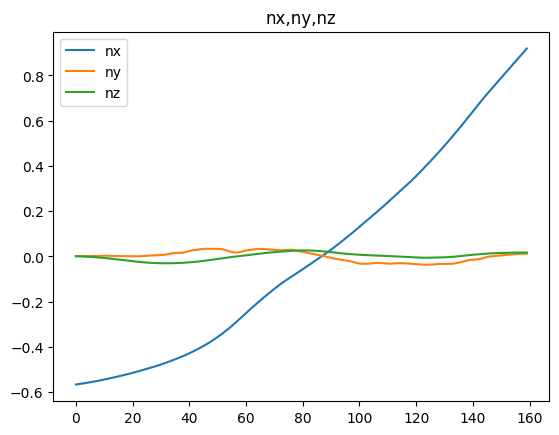

In [30]:
plt.title ("nx,ny,nz")
plt.plot(nx_plt,label="nx")
plt.plot(ny_plt,label="ny")
plt.plot(nz_plt,label="nz")
plt.legend()


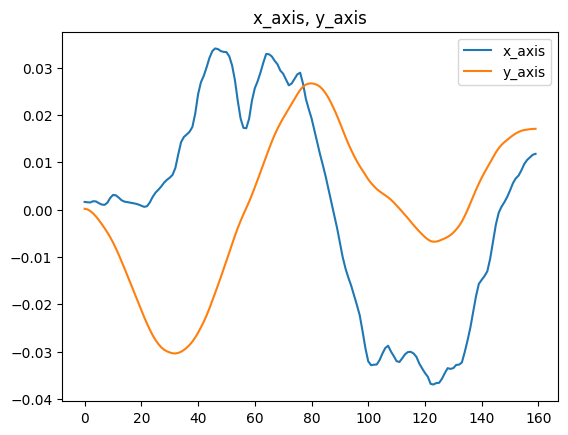

In [31]:
plt.title ("x_axis, y_axis")
plt.plot(x_axis_plt,label="x_axis")
plt.plot(y_axis_plt,label="y_axis")
plt.legend()

In [28]:
unchecked_y = roundf(y_axis * 128.0f));

SyntaxError: invalid decimal literal (1435816227.py, line 1)